# 13 — MFD-PIE: two lasers in one period

Pulsed interleaved excitation puts a second pulse in the same laser period, so
one histogram holds two windows: what the green pulse did, and then what the red
pulse did. Three samples, four detectors, two pulses.

The description changes by two lines against notebook 14 — a second
`Excitation` and `interleaved=True` — and everything else follows from it: the
channel list doubles, and the *six* distinct physics cases appear that a single
pulse does not produce.

Read `11_configuring_the_network.ipynb` first for what a description is.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import experiment as X
import bd
from bd import P


## The description


In [2]:
exp = X.mfd_pie(full=True)
print(exp.summary())


MFD-PIE: 24 histograms
  samples     D0 (donor), A0 (acceptor), DA (donor+acceptor)
  excitations green at 0 ns, reaches donor x 1.0, acceptor x EX_AG, red at 25 ns, reaches acceptor x 1.0, donor x EX_DR
  detectors   gv (green), gh (green), rv (red), rh (red)
  histograms
    D0  gv_vv    parallel      donor
    D0  g2v_vv   parallel      donor (EX_DR)
    D0  gh_vh    perpendicular donor
    D0  g2h_vh   perpendicular donor (EX_DR)
    D0  rv_vv    parallel      donor
    D0  r2v_vv   parallel      donor (EX_DR)
    D0  rh_vh    perpendicular donor
    D0  r2h_vh   perpendicular donor (EX_DR)
    A0  gv_vv    parallel      acceptor directly (EX_AG)
    A0  g2v_vv   parallel      acceptor directly
    A0  gh_vh    perpendicular acceptor directly (EX_AG)
    A0  g2h_vh   perpendicular acceptor directly
    A0  rv_vv    parallel      acceptor directly (EX_AG)
    A0  r2v_vv   parallel      acceptor directly
    A0  rh_vh    perpendicular acceptor directly (EX_AG)
    A0  r2h_vh   perpen

## Six cases, and where they come from

A green and a red pulse both reach both chromophores. What separates them is
how strongly: the green pulse was chosen for the donor and reaches the acceptor
only through the weak path `EX_AG`; the red pulse is the other way round through
`EX_DR`. Crossed with three samples, that gives six distinct physics cases —
and it gives them *by derivation*, not by being listed.


In [3]:
seen = {}
for k, s in exp.scope_table().items():
    seen.setdefault(s, []).append(k)
for i, (s, ks) in enumerate(seen.items(), 1):
    samples = sorted({k[0] for k in ks}); pulse = 'red' if '2' in ks[0][1] else 'green'
    print(f'{i}. {"/".join(samples)} under the {pulse} pulse: {s.describe()}')
print(f'\n{len(seen)} distinct cases over {len(exp.channels)} physics channels')


1. D0 under the green pulse: donor
2. D0 under the red pulse: donor (EX_DR)
3. A0 under the green pulse: acceptor directly (EX_AG)
4. A0 under the red pulse: acceptor directly
5. DA under the green pulse: donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
6. DA under the red pulse: donor (EX_DR) + FRET + acceptor directly

6 distinct cases over 24 physics channels


The prototype has those six written into it as a dictionary. The gate asserts
that the rule reproduces the partition they induce, key by key, without having
been shown it — and it also checks the two literal channel lists.


In [4]:
X.check_against_prototype();


  mfd_pie(full=True)         {'channels': 24, 'scopes': 6}
  mfd_pie(full=False)        {'channels': 12}
  separate_measurements      {'channels': 8, 'scopes': 3}
  mfd_donor_excitation       {'channels': 4, 'scopes': 1}
  magic_angle_minimal        {'channels': 2, 'scopes': 1}
  json                       {'round_trip': 'exact for every geometry'}
PASS: the derived channels and scopes reproduce the hand-written ones


## Two descriptions of the same measurement

`full=True` treats every (sample, pulse) as its own physics channel: twenty-four
of them in twelve histograms, which is what the measurement is. `full=False` is
the earlier route this series was built on, in which only the labelled sample's
red-pulse window is modelled, and it is the one the fit below uses because it is
the route the series has already validated end to end.


In [5]:
short = X.mfd_pie(full=False)
model_bd = bd.build_model(P.default_settings())
assert sorted(short.channel_keys()) == sorted(model_bd['keys'])
print('the description reproduces the twelve channel keys the series fits:')
for k in model_bd['keys']:
    print('   ', k)


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
the description reproduces the twelve channel keys the series fits:
    ('D0', 'gv_vv')
    ('D0', 'gh_vh')
    ('D0', 'rv_vv')
    ('D0', 'rh_vh')
    ('DA', 'gv_vv')
    ('DA', 'gh_vh')
    ('DA', 'rv_vv')
    ('DA', 'rh_vh')
    ('A0', 'g2v_vv')
    ('A0', 'g2h_vh')
    ('A0', 'r2v_vv')
    ('A0', 'r2h_vh')


## What the second laser buys

The identifiability table of the full description, against notebook 12's, which
has one pulse and one sample. The quantity to look at is `EX_AG`, the
probability that the green pulse excites the acceptor directly: with a red pulse
the same molecules are seen twice in one histogram, their ratio measures that
crosstalk, and the table says so.


In [6]:
model = X.build(exp, knots=25)
rows = X.identifiability(exp, model)
by = {r['variable']: r for r in rows}
print(f'{"unknown":<12}{"data share":>11}   carried by')
for n in ('EX_AG', 'x_d0', 'QY_A', 'r0_a', 'w_rho_a', 'g'):
    if n in by:
        r = by[n]
        print(f'{n:<12}{r["data_share"]:>11.4f}   {r["carried_by"]}')
blind = X.unidentified(rows)
print(f'\n{len(blind)} of {len(rows)} unknowns are moved by nothing: '
      + ', '.join(r['variable'] for r in blind))


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt


unknown      data share   carried by
EX_AG            1.0000   A0 rv_vv, A0 rh_vh, A0 gv_vv
x_d0             0.9991   DA r2v_vv, DA r2h_vh, DA gv_vv
QY_A             1.0000   A0 r2v_vv, A0 r2h_vh, A0 rv_vv
r0_a             1.0000   A0 r2v_vv, A0 r2h_vh, A0 rv_vv
w_rho_a          1.0000   A0 r2v_vv, A0 r2h_vh, A0 rv_vv
g                0.9999   A0 g2h_vh, A0 gh_vh, DA gh_vh

3 of 78 unknowns are moved by nothing: log10_lam, bkg_D0_r2v_vv, bkg_D0_r2h_vh


## Data, and the fit

Simulated through the same forward model the fit uses, with Poisson noise, and
fitted by the route this series validated: each labelled histogram carries both
pulses in its mean, and the roughness weight is integrated out over a grid of
nodes mixed by their evidences.


In [7]:
import time
st = P.default_settings()
rel = model_bd['rel']
p_true = (np.exp(-0.5 * ((rel - 0.85) / 0.07) ** 2)
          + 0.6 * np.exp(-0.5 * ((rel - 1.25) / 0.09) ** 2))
p_true = p_true / p_true.sum()
y, lam_true, vals = bd.simulate_ensemble(model_bd, st, p_true, x_d0=0.2, photons=3e5, seed=1)
t0 = time.time()
g, post = bd.fit_ensemble(model_bd, y, lam_nodes=(1.0, 0.0, -1.0), seed=0)
print(f'{time.time() - t0:.0f} s')


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start

25 s


## Rule 0

The Poisson deviance per degree of freedom against a **measured** reference —
Poisson draws at the fitted means — and a runs test on the weighted residuals of
every histogram.


In [8]:
ref_mean, ref_sd = P.poisson_reference(post, n_draw=200, seed=0)
print(f'{"histogram":<14}{"photons":>12}{"D/dof":>9}{"runs p":>9}')
for k, r in post['rows'].items():
    print(f'{k[0] + " " + k[1]:<14}{float(y[k].sum()):>12,.0f}{r["dpd"]:>9.3f}{r["runs_p"]:>9.3f}')
z = (post['dev'] / post['dof'] - ref_mean) / ref_sd
print(f'\nreference D/dof: {ref_mean:.3f} +- {ref_sd:.3f}')
print(f'this fit: {post["dev"] / post["dof"]:.3f}, {z:+.1f} reference sd')
print('VERDICT:', 'passes' if abs(z) < 3 else 'FAILS -- excluded and counted')


histogram          photons    D/dof   runs p
D0 gv_vv           308,974    0.985    0.083
D0 gh_vh           217,181    0.958    0.675
D0 rv_vv            16,373    1.008    0.362
D0 rh_vh            11,486    1.075    0.401
DA gv_vv           314,327    0.982    0.021
DA gh_vh           204,771    0.989    0.657
DA rv_vv           509,135    0.935    0.504
DA rh_vh           406,890    1.003    0.176

reference D/dof: 1.076 +- 0.034
this fit: 0.992, -2.5 reference sd
VERDICT: passes


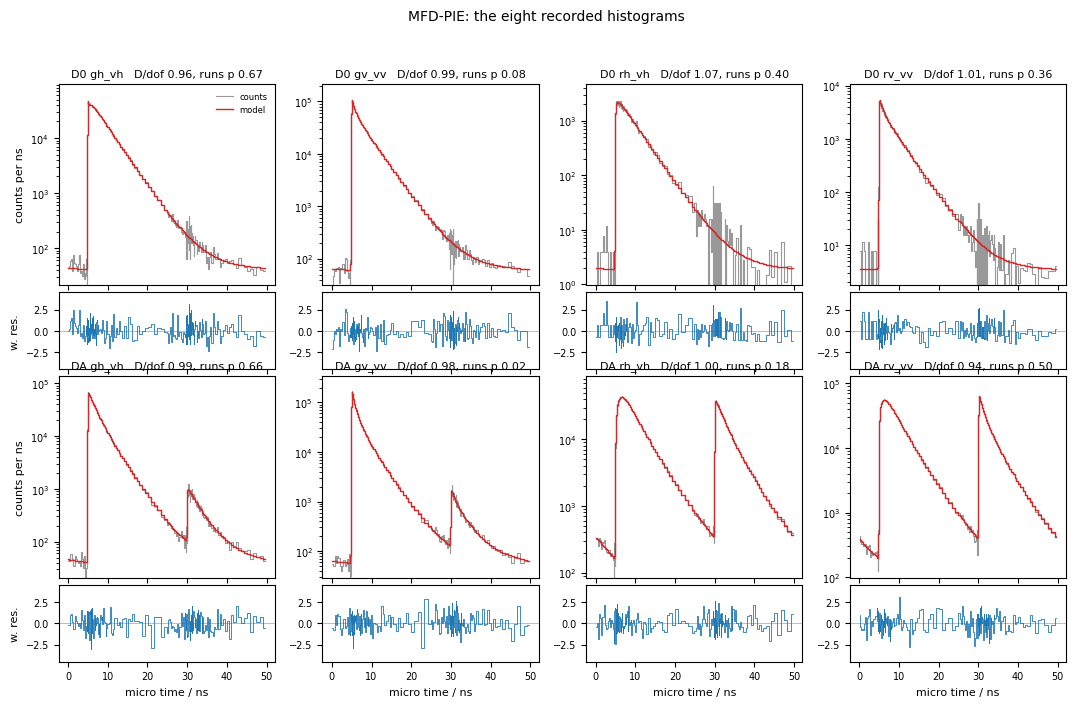

In [9]:
fig = P.plot_decays(model_bd, y, post, title='MFD-PIE: the eight recorded histograms')
plt.show()


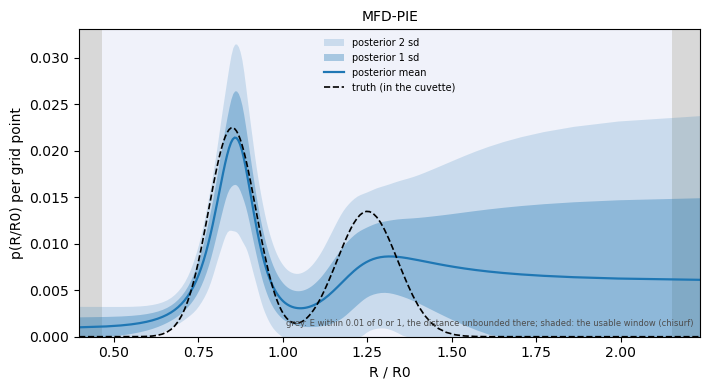

mean R/R0:  truth 0.9746   posterior 1.0264
the evidence mixture put weights [0.7882 0.208  0.0039] on log10 lambda = [1.0, 0.0, -1.0]


In [10]:
fig = P.plot_pR(model_bd, post, p_true=p_true, title='MFD-PIE')
plt.show()
m, lo1, hi1, lo2, hi2 = model_bd['L'].delta_bands(None, post, rel, space='linear')
print(f'mean R/R0:  truth {float((p_true * rel).sum()):.4f}   '
      f'posterior {float((m * rel).sum()):.4f}')
print(f'the evidence mixture put weights {np.round(post["weights"], 4)} on '
      f'log10 lambda = {post["lam_nodes"]}')


## What to take from this

The measurement in this notebook and the one in notebook 14 differ, in the
description, by a second `Excitation` and one boolean. Everything else — twelve
histograms instead of eight, six physics cases instead of three, a second
`g` factor, the donor's excitation by the red laser, and the acceptor's direct
excitation becoming measurable — is derived from those two lines.

That is the point of making the experiment a value rather than a code path. The
alternative, which is what this project had until now, is a second literal
channel list and a second branch in the physics for every experiment anyone
wants to run.
